# Lab 4: EDA - Univariate Analysis
**Author:**
**Date:** 2026-04-20

___

#### Topic Outline:

- Exploratory Data Analysis:
  - Univariate analysis:
    - Producing and interpreting summary statistics for variables.
    - Plots and visualizations for understanding variable distribution.
    - Multiplots.

---

#### Collaboration

You are encouraged to collaborate with other students in your labs, but you are expected to write up your own work for submission. Please do not copy and paste other people's solutions to problems as it is considered plagiarism and you will be penalized and reported. Should you choose to collaborate with others, please note their names here:

**Your name: Aldo Nunez**

**Collaborators:**

1.

___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your lab assignments and to enhance your learning experience. Please make a note of any agents you have used in this submission here:

**Agents: Claude Code**

---

## 1. Introduction

We now know how to load, prepare and visualize data. In this lab we will practice implementing all of these skills to perform **exploratory data analysis**, the process of summarizing variable distributions and relationships. Your focus throughout this lab should not be producing the visualizations or computing the statistics, but instead understanding what information they are providing you. Good exploratory analysis should be thorough, efficient, and well communicated.

In the next chunk we load the required data packages:

In [1]:
# Packages
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set_style("whitegrid")
sns.set_palette("Set2")

In this lab we will be exploring a synthetic data set `student_performance.csv` which contains information on the academic performance of students. This dataset was provided by [Mubashir Ahmed Siddiqui on Kaggle](https://www.kaggle.com/datasets/mubashirsidiki/student-academic-performance-500-students?resource=download). You can download the `.csv` file from **Canvas** and load into Python using the chunk below:

In [2]:
# Load data
df = pd.read_csv(
    'data/student_performance.csv', 
    keep_default_na=False                    # this option prevents "None" strings from being converted to NaN
    )
# Change gender and parent_education to categorical
df[['gender', 'parent_education']] = df[['gender', 'parent_education']].astype('category')

This data has been prepared in advance with the details provided in the lab solutions.  We inspect the first few rows of this prepared data set using `shape` and examine the variable properties using `info`.

In [3]:
# Look at data information
print(df.info())
# Examine first few rows
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   student_id            500 non-null    str     
 1   gender                500 non-null    category
 2   age                   500 non-null    int64   
 3   study_hours_per_week  500 non-null    int64   
 4   attendance_rate       500 non-null    float64 
 5   parent_education      500 non-null    category
 6   internet_access       500 non-null    bool    
 7   extracurricular       500 non-null    bool    
 8   previous_score        500 non-null    int64   
 9   final_score           500 non-null    int64   
 10  passed                500 non-null    bool    
dtypes: bool(3), category(2), float64(1), int64(4), str(1)
memory usage: 26.1 KB
None


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,True,True,41,67,True
1,STU0002,Female,15,2,54.7,Bachelor,True,True,83,28,False
2,STU0003,Female,19,10,90.5,High School,True,False,73,49,False
3,STU0004,Male,16,26,66.8,High School,False,True,75,70,True
4,STU0005,Female,15,25,73.0,High School,False,True,67,77,True


We have a selection of categorical and numerical variables and we are interested in exploring which variables influence students passing the class.  We note that it is likely that the class has some passing final grade in which case the `passed` variable is deterministically given by `final_score` as

$$
\text{passed} = \mathbb{1}(\text{final\_score} > \text{c}),
$$

for some unknown $c$ where $\mathbb{1}$ denotes an indicator function taking a value of $1$ when the condition is satisfied and $0$ otherwise.  It is important that we confirm this first as this would mean that these variables cannot be used to model each other. 

---

## 2. Exploratory Data Analysis

### 2.1 Final Score and Passing

As noted in Section 1, it is likely that students pass the class if they obtain a sufficiently high final score. To check we split our data into failing and passing students and compute the maximum and minimum final score respectively.  

In [4]:
min_pass = df[df['passed']]['final_score'].min().item()
max_fail = df[~df['passed']]['final_score'].max().item()
print(f"Minimum final score for passing students: {min_pass}")
print(f"Maximum final score for failing students: {max_fail}")

Minimum final score for passing students: 50
Maximum final score for failing students: 49


We see that students pass the class if they obtain a score $\geq 50$.  Although `passed` is completely determined by `final_score` we leave both in the data frame to be used as comparisons for categorical and quantitative variables respectively.  We begin by conducting our **univariate analysis** with the aim of understanding the **distributions** of each variable.

### 2.2 Univariate Analysis

#### 2.2.1 Categorical Variables

We start our univariate analysis by considering **categorical variables**. As discussed in lecture, for categorical variables our exploration typically consists of tabulating category counts, proportions, and percentages. In our first short problem we practice our skills at defining functions to compute these measurements for specified variables of a data frame.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q1 Categorical Tabulation

Write a function called `categorical_summary(df, col)` where:

1. `df` specifies the data frame we are considering.
2. `col` specifies the column we are selecting.

The function should return a data frame with rows corresponding to the categories of the selected column and with columns `Count`, `Proportion`, and `Percentage`, which should contain the count, proportion, and percentage of observations for each category value.

Test the function on two categorical columns of your choosing.

---

**Solution:**

In [7]:
def categorical_summary(df, col):
    counts = df[col].value_counts()
    proportions = df[col].value_counts(normalize=True)

    summary = pd.DataFrame({
        'Count': counts,
        'Proportion': proportions,
        'Percentage': proportions * 100
    })

    return summary

categorical_summary(df, 'gender')
categorical_summary(df, 'parent_education')

,Count,Proportion,Percentage
parent_education,,,
None,117,0.234,23.4
Master,100,0.200,20.0
Bachelor,97,0.194,19.4
High School,95,0.190,19.0
PhD,91,0.182,18.2


---

Although informative, producing multiple tables is inefficient and slow to read. Instead, let us produce a multiplot of count plots for each categorical variable. First, to avoid repetitive filtering, we start by isolating categorical variables into the new data frame `df_cat`:

In [8]:
# Isolate categorical and boolean variables as a new data frame
df_cat = (
    df.select_dtypes(include=["object", "category", "str", "bool"])
    .copy()
    .drop(columns=['student_id'])
)
df_cat.head()

,gender,parent_education,internet_access,extracurricular,passed
0,Male,Bachelor,True,True,True
1,Female,Bachelor,True,True,False
2,Female,High School,True,False,False
3,Male,High School,False,True,True
4,Female,High School,False,True,True


Next, we produce the multiplot using the `FacetGrid` function from `seaborn`. This syntax is more complicated, so please **spend some time studying the syntax and reading the comments outlining what each line is doing**. You will be asked to produce a similar multiplot for box plots when we consider numerical variables.

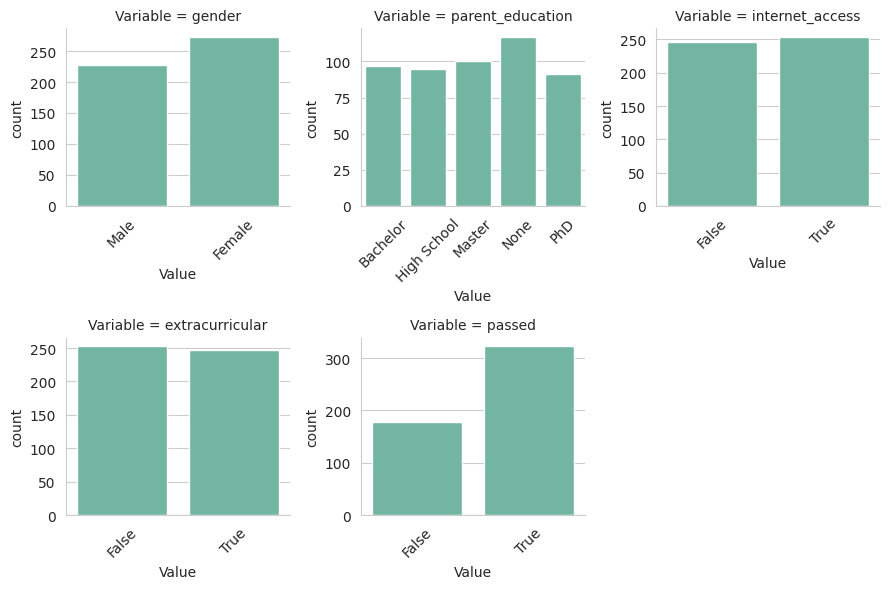

In [9]:
# Use melt to put data into long form
# Each row becomes one (variable, value) pair for faceting.
df_cat_melt = df_cat.melt(
    var_name='Variable',  # Name of the new column that stores original column names.
    value_name='Value'    # Name of the new column that stores category values.
)

# Helper function that draws one countplot per facet.
def facet_countplot(data, color=None, **kwargs):
    sns.countplot(
        data=data,         # Subset of rows passed in by FacetGrid for this facet.
        x='Value',         # Categorical values go on the x-axis.
        color=color,       # Single color provided by FacetGrid/palette.
        **kwargs           # Accept extra plotting args from map_dataframe.
    )

# Build a grid of subplots, one panel per categorical variable.
g = sns.FacetGrid(
    df_cat_melt,          # Long-form data source for all facets.
    col='Variable',       # Create one column panel per variable name.
    col_wrap=3,           # Wrap after 3 panels per row.
    sharex=False,         # Let each panel have its own x-axis categories.
    sharey=False          # Let each panel have its own y-axis scale.
)

g.map_dataframe(facet_countplot)  # Apply the helper function to each facet.
g.set_xticklabels(rotation=45)     # Rotate x labels to reduce overlap.

plt.tight_layout()  # Adjust spacing so labels/titles fit cleanly.
plt.show()          # Render the faceted plot.

Do you see anything of interest? Get into the habit of commenting on every table and figure you produce! In this case you might be looking to see if any variables have distributions you would not expect. One quick observation is that some of the distributions are much more uniform than would be expected in real data. For example, roughly half of the students not having internet access and an approximately even distribution of parent education levels seems unlikely in reality.

---

### 2.2.2 Quantitative Variables

Next we consider quantitative variables. We begin again by isolating quantitative variables in their own data frame `df_num`: 

In [10]:
# Isolate numerical variables as a new data frame
df_num = df.select_dtypes(include=["int64", "float64"]).copy()
df_num.head()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
0,15,25,63.8,41,67
1,15,2,54.7,83,28
2,19,10,90.5,73,49
3,16,26,66.8,75,70
4,15,25,73.0,67,77


<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2 Summary Statistics

Recall the `describe` function which produces a table of summary statistics for numerical variables.  An example of this output (with values rounded to 2DP) is shown below:

In [11]:
df_num.describe().round(2)

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.00,500.00,500.00,500.00,500.00
mean,16.98,15.31,76.38,62.99,55.98
std,1.43,8.57,13.82,18.94,15.37
min,15.00,2.00,50.20,30.00,20.00
25%,16.00,8.00,64.47,46.00,45.00
50%,17.00,15.00,76.50,64.00,56.00
75%,18.00,23.00,88.52,79.00,68.00
max,19.00,30.00,100.00,95.00,95.00


Write a function `quantitative_summary` that produces a modified version of this output with the following rows added to the bottom:

1. `median` - the 50% percentile.
2. `range` - difference between the maximum and minimum.
3. `iqr` - difference between the upper and lower quartile.
4. `std` - the standard deviation (look up how to compute this in numpy).

If you need to, look up the pandas functions for computing these statistics. You can use `concat` to combine the describe output data frame with one you create with these additional statistics. Depending on your construction you may need to transpose one of the data frames.

---

**Solution:**

In [15]:
def quantitative_summary(df, col):
    base = df[col].describe().to_frame()

    extra = pd.DataFrame({
        col:{
            'median': df[col].median(),
            'range' : df[col].max() - df[col].min(),
            'iqr': df[col].quantile(0.75) - df[col].quantile(0.25),
            'std': np.std(df[col])
        }
    })

    return pd.concat([base, extra])

quantitative_summary(df_num, 'age')

,age
count,500.000000
mean,16.978000
std,1.434445
min,15.000000
25%,16.000000
50%,17.000000
75%,18.000000
max,19.000000
median,17.000000
range,4.000000


---



As discussed in lecture, the standard plots used to perform univariate analysis on numerical variables are box plots (which visualize the quartiles and outliers) and histograms (which visualize the distribution shapes).

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3 Multiplots

Using the count plot multiplot syntax as a guide produce two multiplots for the quantitative variables of our data set, one containing the box plots and the other histograms.  Under each plot, briefly discuss your findings.

---

**Solution:**

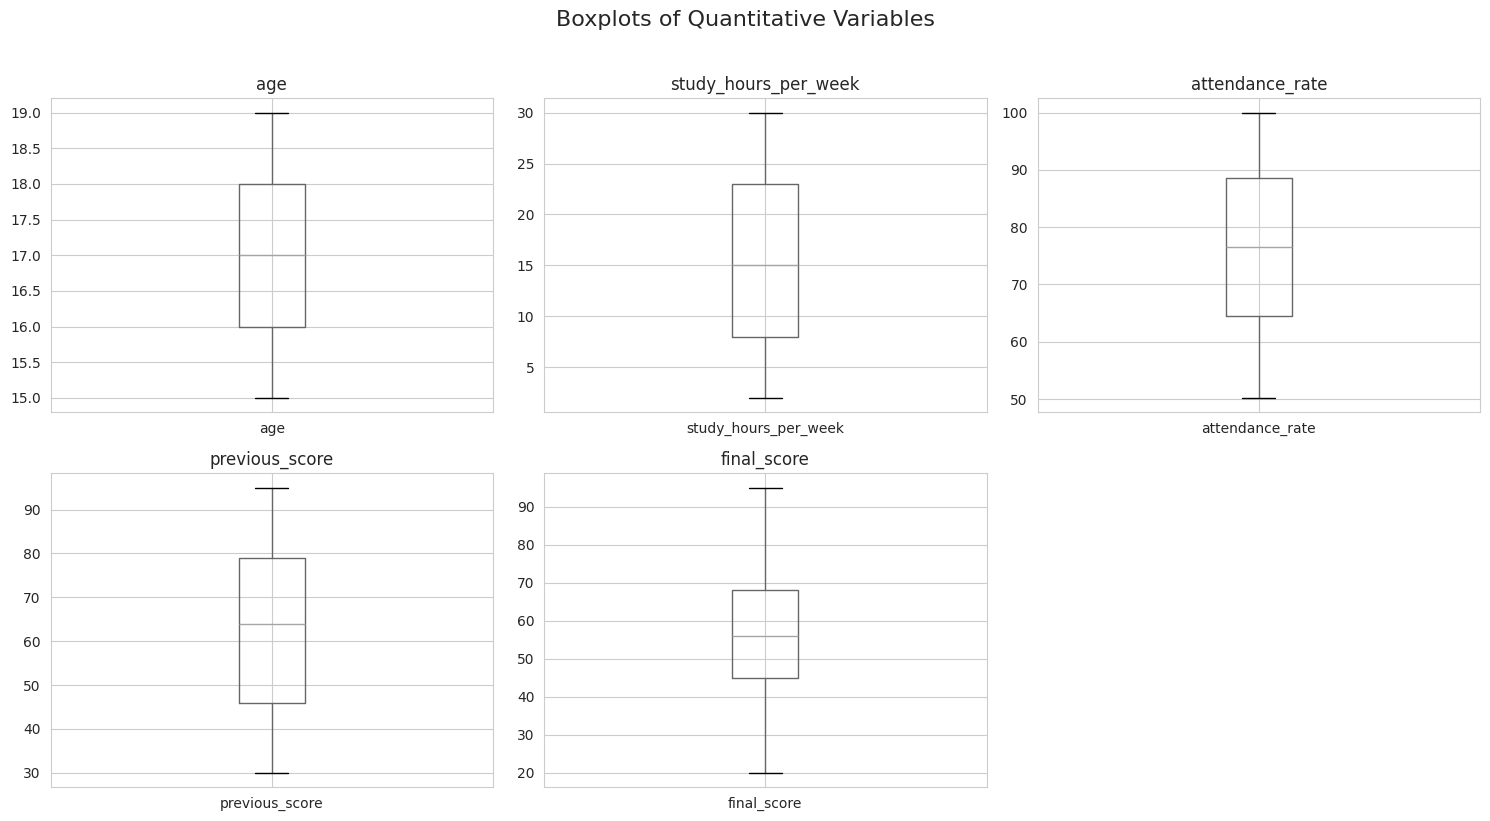

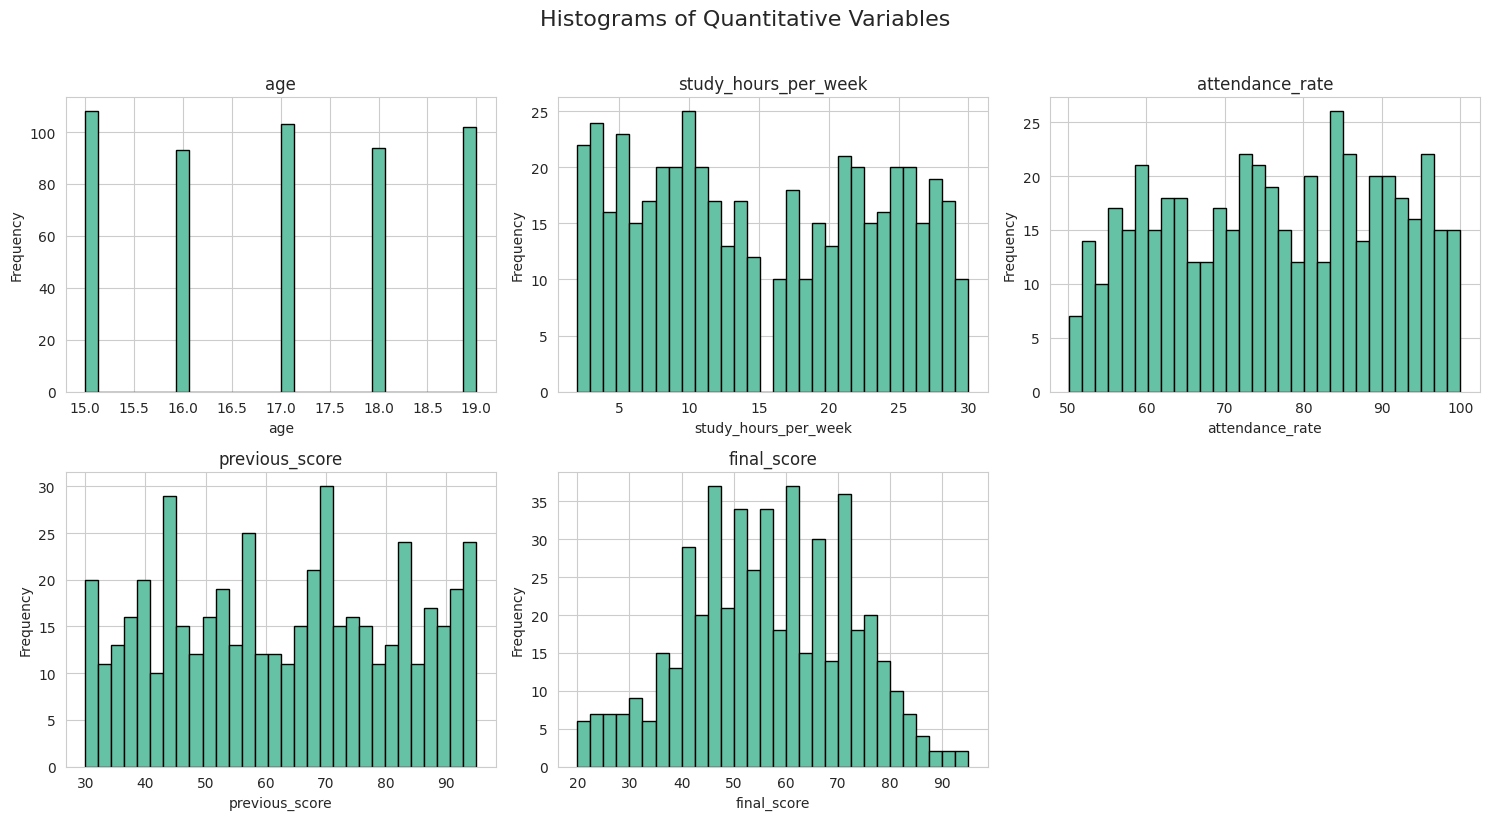

In [16]:
# Boxplot multiplot
quant_cols = df.select_dtypes(include='number').columns
n = len(quant_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Quantitative Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# Histogram multiplot
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    df[col].plot(kind='hist', ax=axes[i], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of Quantitative Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---

Next week we will continue our exploration of this data set, focusing on multivariate analysis and specifically identifying any evidence of relationships with the variable of interest `final_score`.  This will lead us nicely towards thinking about variables more formally as dependent and independent variables and considering potential models such as linear regression.

---

## Submission Checklist

- Ensure you have completed all problems in the notebook.
- Clear your document code outputs and rerun the notebook, checking for any new errors.
- At the top of your notebook click more options -> export -> pdf.
  - Alternatively, export to html and save as a pdf.
- Make sure your pdf has all code chunks clearly visible and executed.
- Submit before the posted deadline. 